# Building an Inverted Index and Answering Queries

**Information Retrieval — Lab 04**

In this lab you will implement a complete (if small) search engine, following the classic document-processing pipeline:

```
crawl  ──►  parse  ──►  preprocess  ──►  index  ──►  query (Boolean / BM25)
```

**Learning objectives.** By the end of the lab you should be able to:

1. build a reusable text-preprocessing pipeline (tokenization, normalization, stop-word removal, stemming);
2. write a polite, bounded breadth-first web crawler;
3. construct an inverted index with collection frequencies and postings lists;
4. answer queries with **Boolean retrieval** (postings intersection, *IIR* ch. 1);
5. rank documents with **Okapi BM25** and inspect the effect of its parameters.

**Running the notebook.** Run the cells top to bottom. Crawling needs internet access; if the target site is unreachable (no network, firewall, HTTP 403), the notebook automatically falls back to a small built-in offline corpus, so every section below still runs.

## 0. Setup

Install the dependencies once (uncomment the line below in Colab or a fresh environment).

In [1]:
!uv add nltk beautifulsoup4 requests matplotlib

Resolved 128 packages in 10ms
Checked 77 packages in 581ms


In [2]:
!uv tree -d 1

Resolved 128 packages in 6ms
ir v0.1.0
├── beautifulsoup4 v4.15.0
├── bs4 v0.0.2
├── feedparser v6.0.14
├── ipykernel v7.3.0
├── matplotlib v3.10.9
├── nltk v3.10.3
├── pandas v2.3.3
├── requests v2.34.2
├── selenium v4.48.0
└── statsmodels v0.15.0


In [3]:
import hashlib
import math
import os
import pickle
import re
import time
from collections import Counter, deque
from heapq import nlargest
from urllib.parse import urldefrag, urljoin, urlparse
from urllib.robotparser import RobotFileParser

import nltk
import requests
from bs4 import BeautifulSoup, SoupStrainer

# ---- global configuration -------------------------------------------------
BASE_DOMAIN = "www.nbcnews.com"
BASE_URL = f"https://{BASE_DOMAIN}"
USER_AGENT = "IR-Course-Lab04-Crawler/1.0 (educational use)"
REQUEST_TIMEOUT = 10      # seconds per HTTP request
CRAWL_DELAY = 0.2         # seconds between requests (politeness)

# Tokenizer models: newer NLTK versions use 'punkt_tab', older ones 'punkt'.
for _pkg in ("punkt_tab", "punkt"):
    try:
        nltk.download(_pkg, quiet=True)
    except Exception:
        pass

## 1. Preprocessing

Documents and queries **must** be processed by exactly the same pipeline, otherwise query terms will not match index terms. The `Preprocessor` below:

1. lowercases and tokenizes the text (`nltk.word_tokenize`);
2. drops tokens that are stop words or are not purely alphabetic (punctuation, numbers, dates);
3. stems the remaining tokens with the Porter stemmer.

Stemming is the most expensive step and a news collection repeats the same words constantly, so stems are memoized in a dictionary. If the NLTK tokenizer models cannot be downloaded, a regex tokenizer with the same behaviour on ordinary text is used instead.

In [ ]:
class Preprocessor:
    # A small, classic stop-word list (the one used in many IR textbooks).
    STOP_WORDS = frozenset({
        'a', 'an', 'and', 'are', 'as', 'at', 'be', 'by', 'for', 'from', 'has', 'he',
        'in', 'is', 'it', 'its', 'of', 'on', 'that', 'the', 'to', 'was', 'were',
        'will', 'with'})

    _FALLBACK_TOKEN_RE = re.compile(r"\w+|[^\w\s]")
    _warned = False

    def __init__(self):
        self.stop_words = self.STOP_WORDS
        self.ps = nltk.stem.PorterStemmer()
        self._stem_cache = {}
        try:
            nltk.word_tokenize("probe")
            self._tokenizer = nltk.word_tokenize
        except LookupError:
            if not Preprocessor._warned:
                print("NLTK tokenizer models unavailable -> using regex tokenizer.")
                Preprocessor._warned = True
            self._tokenizer = self._FALLBACK_TOKEN_RE.findall

    def tokenize(self, text):
        # Word-tokenize text.
        #TODO word tokenize text using nltk lib

        return ...

    def stem(self, word, stemmer):
        # Stem a word with the given stemmer (memoized for the default stemmer).
        #TODO stem word using provided stemmer

        return ...

    def is_apt_word(self, word):
        # A word is kept if it is not a stop word and consists of letters only.
        #TODO check if word is appropriate - not a stop word and isalpha,
        # i.e consists of letters, not punctuation, numbers, dates
        return ...

    def preprocess(self, text):
        
        # Full pipeline: lowercase -> tokenize -> filter -> stem.
        return [self.stem(w, self.ps)
                for w in self.tokenize(text.lower())
                if self.is_apt_word(w)]

### Tests

In [5]:
prep = Preprocessor()
text = 'To be, or not to be, that is the question'

assert prep.tokenize(text) == ['To', 'be', ',', 'or', 'not', 'to', 'be', ',', 'that', 'is', 'the', 'question']
assert prep.stem('retrieval', prep.ps) == 'retriev'
assert prep.is_apt_word('qwerty123') is False
assert prep.is_apt_word('the') is False
assert prep.preprocess(text) == ['or', 'not', 'question']
assert prep.preprocess('') == []

text = 'To be, or not to be, that is the question U.S. covid19 2024'
prep.preprocess(text)

['or', 'not', 'question']

> **Discussion.** The filter drops `"covid19"`, `"U.S."` and `"2024"`. When is that acceptable, and how would you keep such tokens? What does stemming do to precision and recall?

## 2. Documents: downloading and parsing

### 2.1 Base class

`Document` downloads a URL and persists it on disk.

Improvements over a naive implementation:

* a shared `requests.Session` (connection reuse), a descriptive `User-Agent`, and a timeout, so one slow server cannot freeze the crawler;
* non-HTML responses (PDF, video, images, …) are rejected by their `Content-Type` header, not only by their file extension;
* **persisted file names are SHA-1 hashes of the URL.** Using the quoted URL as a file name (the original approach) breaks because URLs can be longer than the 255-character file-name limit, contain characters that are illegal on some file systems, and different URLs can collide after `'/' → '_'` replacement.

In [ ]:
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


class Document:

    def __init__(self, url):
        self.url = url
        self.content = None

    def download(self):
        # Fetch the page; return True only for a successful HTML response.
        try:
            response = SESSION.get(self.url, timeout=REQUEST_TIMEOUT)
        except requests.RequestException:
            return False
        if response.status_code != 200:
            return False
        if "html" not in response.headers.get("Content-Type", "html"):
            return False
        self.content = response.content
        return True

    @property
    def file_name(self):
        #TODO: build filenames for the crawled pages.
        return ...

    def persist(self, path):
        # this code is not supposed to be good :)
        # Please discuss why this line is bad
        from urllib.parse import quote
        with open(os.path.join(path, quote(self.url).replace('/', '_')), 'wb') as f:
            f.write(self.content)
        

### 2.2 Site-specific article parser

Full HTML parsing is expensive, and the crawler does not always need it: for navigation pages it only needs the **links**, while for articles it needs the **text** as well. The class therefore parses lazily:

* `anchors` parses **only `<a href>` tags** (via `SoupStrainer`) unless a full parse is already cached; The SoupStrainer class allows you to choose which parts of an incoming document are parsed.
* `article_text` performs a full parse once and caches the tree.

Text extraction relies on stable, semantic structure: the `<h1>` title plus the `<p>` paragraphs inside `<article>` (or `<main>`). The schema.org `articleBody` in the page's JSON-LD metadata is used when available.

> **Discussion.** Why is selecting content by CSS classes such as `article-body__content__17Yit` a bad strategy? *(Hint: such suffixes are generated by CSS-in-JS build tools and change on every front-end deployment.)*

In [ ]:
import json as _json


class NBCNewsArticle(Document):

    def __init__(self, url):
        super().__init__(url)
        self._soup = None
        self._anchors = None
        self._text = None

    # -- helpers --------------------------------------------------------------
    def normalize(self, href):
        # Make a link absolute, drop fragments and query strings.
        if not href:
            return None
        href = urljoin(self.url, href.strip())
        href, _ = urldefrag(href)
        return href.split("?", 1)[0]

    def _full_soup(self):
        if self._soup is None:
            self._soup = BeautifulSoup(self.content, "html.parser")
        return self._soup

    # -- lazy fields ----------------------------------------------------------
    @property
    def anchors(self):
        # List of (anchor_text, absolute_url); parses only <a> tags if possible.
        if self._anchors is None:
            ...
            # TODO
        return self._anchors

    @property
    def article_text(self):
        # Title + body text of the article ('' if nothing useful is found).
        if self._text is None:
            ...
            # TODO
        return self._text

    def parse(self):
        # Kept for backward compatibility: forces both fields to be computed.
        return self.anchors, self.article_text

    @staticmethod
    def _json_ld_body(soup):
        for script in soup.find_all("script", type="application/ld+json"):
            ...
            # TODO
        return ...

    @staticmethod
    def _paragraph_body(soup):
        # TODO
        return ...

A quick offline check of the parser on a hand-made page (no network needed):

In [8]:
_html = b'''
<html><head><title>ignored</title><script>var x = 1;</script></head>
<body>
  <nav><a href="/politics">Politics</a> <a href="https://example.org/x">External</a></nav>
  <article>
    <h1>Test headline</h1>
    <p>First paragraph.</p>
    <p>Second paragraph with a <a href="/news/us-news/some-story-rcna123#top">link</a>.</p>
  </article>
</body></html>'''

d = NBCNewsArticle("https://www.nbcnews.com/news/test-page")
d.content = _html
assert d.anchors[0] == ("Politics", "https://www.nbcnews.com/politics")
assert d.anchors[2][1] == "https://www.nbcnews.com/news/us-news/some-story-rcna123"
assert d.article_text.startswith("Test headline\nFirst paragraph.")
assert "var x" not in d.article_text
print("Parser: all tests passed")

Parser: all tests passed


And on live pages (skipped gracefully if the site is unreachable):

In [9]:
for url in ["https://www.nbcnews.com/news/us-news/jeff-bezos-sells-nearly-12-million-amazon-shares-least-2-billion-come-rcna138274",
            "https://www.nbcnews.com/news/us-news/nbc-affiliates-n19981"]:
    doc = NBCNewsArticle(url)
    if doc.download():
        print(doc.article_text[:400], "...\n")
    else:
        print(f"Could not download {url} (offline or blocked) — skipping.\n")

Jeff Bezos sells nearly 12 million Amazon shares worth at least $2 billion, with more to come
SEATTLE — Jeff Bezos filed a statement with federal regulators indicating his sale of nearly 12 million shares of Amazon stock worth more than $2 billion. The Amazon executive chairman notified the U.S. Securities and Exchange Commission of the sale of 11,997,698 shares of common stock on Feb. 7 and Feb.  ...

NBC Affiliates
Alabama WVTM Birmingham, AL www.wvtm13.com WAFF Huntsville, AL www.waff.com WPMI Mobile, AL www.local15tv.com WSFA Montgomery, AL www.wsfa.com Alaska KTUU Anchorage, AK www.ktuu.com KTVF Fairbanks, AK www.webcenter11.com KATH Juneau, AK www.kath.tv Arizona KNAZ Flagstaff, AZ www.12news.com KAIT Jonesboro, AZ www.kait8.com KPNX Phoenix, AZ www.12news.com KVOA Tucson, AZ www.kvoa.com  ...



## 3. Crawling and indexing

### 3.1 The indexer

`NBCNewsIndexer.crawl_generator_for_index(source, depth, collection_path, limit)` performs a **breadth-first crawl** starting from `source`:

* only inner pages (`https://www.nbcnews.com/...`) are followed, and non-HTML resources (`.pdf`, `.mp3`, `.mp4`, …) are skipped;
* `robots.txt` is respected and requests are spaced by `CRAWL_DELAY` seconds;
* a URL is marked *seen* when it is **enqueued**, not when it is dequeued, so the queue never holds duplicates;
* **article pages** are recognized by NBC's article-ID suffix (e.g. `...-rcna138274`, `...-n19981`). Section pages such as `/news/weather` are crawled for links but not indexed;
* every article is saved in `collection_path`, added to the index, and yielded to the caller, which prints its URL.

The index keeps three dictionaries:

| dictionary     | structure |
|----------------|-----------|
| `doc_urls`     | `{doc_id: url}` |
| `index`        | `{term: [collection_frequency, (doc_id_1, tf_1), (doc_id_2, tf_2), ...]}` |
| `doc_lengths`  | `{doc_id: number_of_terms}` |

Because doc ids are assigned in increasing order, **every postings list is sorted by `doc_id`**, which Boolean retrieval exploits later.

When the crawl finishes, the three dictionaries are pickled to `index_path`. If `limit` is given (testing mode), the crawl stops after `limit` articles and nothing is written; call `save()` explicitly if you want to keep the result.

In [ ]:
class NBCNewsIndexer:

    ARTICLE_RE = re.compile(r"^https://www\.nbcnews\.com/.+-(?:rcna|ncna|n)\d+/?$")
    SKIP_EXTENSIONS = (".pdf", ".mp3", ".mp4", ".avi", ".mov", ".txt", ".jpg", ".jpeg",
                       ".png", ".gif", ".svg", ".zip", ".xml", ".rss", ".json", ".css", ".js")

    def __init__(self):
        self.doc_urls = {}
        self.index = {}
        self.doc_lengths = {}
        self.prep = Preprocessor()
        self._robots = None

    # ------------------------------------------------------------------ crawl
    def crawl_generator_for_index(self, source, depth, collection_path="collection",
                                  limit=None, index_path="index", max_visits=2000):
        os.makedirs(collection_path, exist_ok=True)
        queue = deque([(source, 0)])
        seen = {source}
        visits = 0

        # Breadth-first Crawl
        while queue and visits < max_visits:
            url, url_depth = queue.popleft()
            # TODO


        self.save(index_path)

    # ------------------------------------------------------------------ filters
    def accepted_url(self, anchor):
        url = anchor[1]
        if not url:
            return False
        parsed = urlparse(url)
        return (parsed.scheme == "https"
                and parsed.netloc == BASE_DOMAIN
                and not parsed.path.lower().endswith(self.SKIP_EXTENSIONS))

    def is_article(self, url):
        return bool(self.ARTICLE_RE.match(url))

    def allowed_by_robots(self, url):
        if self._robots is None:
            self._robots = RobotFileParser()
            try:
                r = SESSION.get(BASE_URL + "/robots.txt", timeout=REQUEST_TIMEOUT)
                self._robots.parse(r.text.splitlines() if r.status_code == 200 else [])
            except requests.RequestException:
                self._robots.parse([])            # unreachable -> allow everything
        return self._robots.can_fetch(USER_AGENT, url)

    # ------------------------------------------------------------------ indexing
    def index_doc(self, doc, doc_id):
        # Index a downloaded document. Returns False if it has no usable text.
        return self.index_text(doc.article_text, doc.url, doc_id)

    def index_text(self, text, url, doc_id=None):
        # Add raw text to the index (also used for the offline corpus).
        terms = self.prep.preprocess(text)
        if not terms:
            return False
        
       # TODO
       
        return True

    # ------------------------------------------------------------------ persistence
    def save(self, index_path="index"):
        os.makedirs(index_path, exist_ok=True)
        for name in ("doc_urls", "index", "doc_lengths"):
            with open(os.path.join(index_path, f"{name}.pkl"), "wb") as f:
                pickle.dump(getattr(self, name), f, protocol=pickle.HIGHEST_PROTOCOL)

    @classmethod
    def load(cls, index_path="index"):
        obj = cls()
        for name in ("doc_urls", "index", "doc_lengths"):
            with open(os.path.join(index_path, f"{name}.pkl"), "rb") as f:
                setattr(obj, name, pickle.load(f))
        return obj

### 3.2 Tests

In [ ]:
# Offline unit tests of the indexing logic
t = NBCNewsIndexer()
t.index_text("Retrieval of documents. Document retrieval!", "u0")
t.index_text("Documents about indexing", "u1")
assert t.index["retriev"] == [2, (0, 2)]
assert t.index["document"] == [3, (0, 2), (1, 1)]
assert t.doc_lengths == {0: 4, 1: 3}
assert t.is_article("https://www.nbcnews.com/news/us-news/nbc-affiliates-n19981")
assert not t.is_article("https://www.nbcnews.com/news/weather")
assert t.accepted_url(("x", "https://www.nbcnews.com/politics"))
assert not t.accepted_url(("x", "https://www.nbcnews.com/file.pdf"))
assert not t.accepted_url(("x", "https://example.com/news"))
print("Indexer: all offline tests passed ✔")

Indexer: all offline tests passed ✔


A small live crawl (15 articles). It prints every indexed URL as it runs.

In [12]:
def site_reachable(url=BASE_URL):
    try:
        return SESSION.get(url, timeout=REQUEST_TIMEOUT).status_code == 200
    except requests.RequestException:
        return False

ONLINE = site_reachable()
print("Site reachable:", ONLINE)

if ONLINE:
    indexer = NBCNewsIndexer()
    for k, c in enumerate(indexer.crawl_generator_for_index(
            source="https://www.nbcnews.com/news",
            depth=2,
            collection_path="test_collection",
            limit=15), start=1):
        print(k, c.url)

    assert isinstance(indexer.index, dict)
    some_term = next(iter(indexer.index))
    assert isinstance(indexer.index[some_term], list)
    assert isinstance(indexer.index[some_term][0], int)
    assert isinstance(indexer.index[some_term][1], tuple)
    print("Live crawl tests passed ✔")
else:
    print("Skipping the live crawl test.")

Site reachable: True
1 https://www.nbcnews.com/select/shopping/early-october-prime-day-deals-2026-rcna597786
2 https://www.nbcnews.com/news/nbc-news-now-live-audio-listen-live-news-audio-day-rcna70163
3 https://www.nbcnews.com/tech/tech-news/mark-zuckerberg-interview-connect-audio-glasses-muse-ai-killing-us-rcna599257
4 https://www.nbcnews.com/politics/trump-administration/cnn-politico-ms-now-trump-court-white-house-media-ban-rcna599269
5 https://www.nbcnews.com/news/us-news/harvey-weinstein-sentenced-15-years-new-york-sex-crime-conviction-rcna599213
6 https://www.nbcnews.com/news/us-news/sunny-hostin-holdout-juror-butcher-tompkins-square-park-rcna599515
7 https://www.nbcnews.com/sports/nfl/giants-quarterback-jaxson-dart-undergo-season-ending-knee-surgery-repo-rcna599430
8 https://www.nbcnews.com/news/us-news/dolly-partons-estate-accuses-nephew-threatening-destroy-aunts-legacy-rcna599184
9 https://www.nbcnews.com/news/us-news/chris-spatola-espn-college-basketball-analyst-dies-suddenly-

### 3.3 Building the index

Crawl up to 100 articles from the home page (depth 3) and save the index. If the site is unreachable, or the crawl finds no articles, a small **offline corpus** is indexed instead so the rest of the lab still works.

In [13]:
OFFLINE_CORPUS = [
    ("offline://skin-care-routine",
     "Dermatologists share a simple skin care routine. A gentle cleanser, a moisturizer and "
     "daily sunscreen are the basics of healthy skin care, experts say."),
    ("offline://best-moisturizers",
     "The best face moisturizers for dry skin. We asked skin experts which creams keep skin "
     "hydrated through the winter."),
    ("offline://presidential-election-polls",
     "New polls show a tight presidential election race. Voters in swing states say the "
     "economy is their top concern ahead of the election."),
    ("offline://election-debate",
     "Candidates clash over taxes and health care in the final presidential debate before "
     "the election."),
    ("offline://climate-report",
     "A new climate report warns that global temperatures keep rising. Scientists call for "
     "faster cuts to emissions to limit climate change."),
    ("offline://stock-market",
     "The stock market closed higher as tech shares rallied. Investors are watching the "
     "central bank's next interest rate decision."),
    ("offline://hurricane-season",
     "Forecasters expect an active hurricane season. Coastal residents are urged to prepare "
     "emergency kits and evacuation plans."),
    ("offline://space-launch",
     "A private rocket launched a crew to the space station. The mission will test new "
     "life support systems for longer flights."),
    ("offline://health-care-costs",
     "Rising health care costs worry families. A survey finds many people delay care because "
     "of high prices."),
    ("offline://tech-ai-chips",
     "Tech companies race to build faster AI chips as demand for data centers grows and the "
     "stock market rewards chip makers."),
]

indexer = NBCNewsIndexer()
if ONLINE:
    for k, c in enumerate(indexer.crawl_generator_for_index(
            "https://www.nbcnews.com/", 3, "docs_collection", limit=100), start=1):
        print(k, c.url)
    indexer.save("index")          # limit was given -> save explicitly

if not indexer.doc_urls:
    print("Using the offline corpus.")
    for url, text in OFFLINE_CORPUS:
        indexer.index_text(text, url)
    indexer.save("index")

print(f"\nIndexed {len(indexer.doc_urls)} documents.")

1 https://www.nbcnews.com/select/shopping/early-october-prime-day-deals-2026-rcna597786
2 https://www.nbcnews.com/news/nbc-news-now-live-audio-listen-live-news-audio-day-rcna70163
3 https://www.nbcnews.com/tech/tech-news/mark-zuckerberg-interview-connect-audio-glasses-muse-ai-killing-us-rcna599257
4 https://www.nbcnews.com/politics/trump-administration/cnn-politico-ms-now-trump-court-white-house-media-ban-rcna599269
5 https://www.nbcnews.com/news/us-news/harvey-weinstein-sentenced-15-years-new-york-sex-crime-conviction-rcna599213
6 https://www.nbcnews.com/news/us-news/sunny-hostin-holdout-juror-butcher-tompkins-square-park-rcna599515
7 https://www.nbcnews.com/sports/nfl/giants-quarterback-jaxson-dart-undergo-season-ending-knee-surgery-repo-rcna599430
8 https://www.nbcnews.com/news/us-news/dolly-partons-estate-accuses-nephew-threatening-destroy-aunts-legacy-rcna599184
9 https://www.nbcnews.com/news/us-news/chris-spatola-espn-college-basketball-analyst-dies-suddenly-47-rcna599385
10 http

### 3.4 Index statistics

Load the saved index from disk and inspect it. Note the distinction between

* **document frequency** `df(t)` = number of documents containing `t` = `len(postings) - 1` (the first element is the collection frequency), and
* **collection frequency** `cf(t)` = total number of occurrences of `t` in the collection.

In [14]:
indexer = NBCNewsIndexer.load("index")

n_docs = len(indexer.doc_lengths)
n_tokens = sum(indexer.doc_lengths.values())
print(f"Documents:            {n_docs}")
print(f"Vocabulary size:      {len(indexer.index)}")
print(f"Tokens (after prep):  {n_tokens}")
print(f"Average doc length:   {n_tokens / n_docs:.1f}")

def df(term):
    return len(indexer.index[term]) - 1

top_df = nlargest(20, indexer.index, key=lambda t: (df(t), t))
print("\nTop stems by document frequency:")
print([(t, df(t)) for t in top_df])

top_cf = nlargest(20, indexer.index, key=lambda t: (indexer.index[t][0], t))
print("\nTop stems by collection frequency:")
print([(t, indexer.index[t][0]) for t in top_cf])

Documents:            100
Vocabulary size:      5213
Tokens (after prep):  40397
Average doc length:   404.0

Top stems by document frequency:
[('s', 84), ('not', 64), ('thi', 62), ('have', 61), ('said', 59), ('who', 58), ('more', 56), ('but', 56), ('about', 56), ('or', 54), ('over', 53), ('which', 52), ('they', 52), ('also', 52), ('new', 51), ('say', 49), ('after', 49), ('year', 48), ('when', 48), ('one', 48)]

Top stems by collection frequency:
[('s', 755), ('said', 464), ('you', 292), ('trump', 289), ('hi', 247), ('have', 245), ('thi', 222), ('i', 218), ('not', 215), ('they', 195), ('or', 189), ('more', 174), ('also', 164), ('news', 161), ('say', 156), ('who', 154), ('their', 153), ('can', 152), ('we', 151), ('presid', 151)]


In [15]:
some_stem = top_df[0]
print(f"Postings for '{some_stem}':", indexer.index[some_stem])
for doc_id, tf in indexer.index[some_stem][1:]:
    print(f"  tf={tf:<3} {indexer.doc_urls[doc_id]}")

Postings for 's': [755, (0, 22), (2, 2), (3, 13), (4, 6), (5, 4), (6, 5), (7, 18), (8, 2), (9, 5), (10, 3), (11, 26), (12, 9), (13, 4), (14, 9), (15, 1), (16, 7), (17, 2), (19, 36), (20, 7), (21, 1), (22, 3), (24, 15), (27, 2), (28, 9), (29, 27), (30, 9), (31, 15), (32, 2), (33, 7), (34, 8), (35, 4), (36, 17), (37, 2), (38, 8), (39, 8), (40, 2), (41, 15), (42, 3), (43, 15), (44, 12), (45, 13), (46, 9), (47, 7), (48, 9), (49, 13), (50, 1), (51, 1), (52, 6), (54, 17), (55, 1), (56, 1), (57, 4), (58, 1), (60, 16), (61, 56), (63, 1), (66, 1), (68, 2), (69, 1), (70, 10), (71, 10), (73, 3), (74, 1), (76, 17), (77, 8), (78, 1), (79, 9), (80, 11), (81, 3), (82, 11), (84, 7), (85, 10), (87, 2), (88, 12), (89, 11), (90, 2), (91, 5), (92, 35), (93, 11), (94, 12), (95, 11), (96, 9), (97, 7), (98, 12)]
  tf=22  https://www.nbcnews.com/select/shopping/early-october-prime-day-deals-2026-rcna597786
  tf=2   https://www.nbcnews.com/tech/tech-news/mark-zuckerberg-interview-connect-audio-glasses-muse-ai-

**Zipf's law.** Plotting collection frequency against rank on log–log axes should give roughly a straight line.

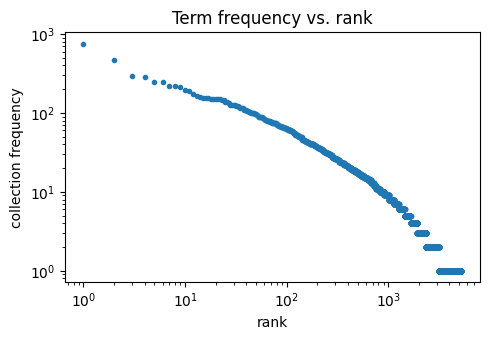

In [16]:
import matplotlib.pyplot as plt

freqs = sorted((p[0] for p in indexer.index.values()), reverse=True)
plt.figure(figsize=(5, 3.5))
plt.loglog(range(1, len(freqs) + 1), freqs, marker=".", linestyle="none")
plt.xlabel("rank")
plt.ylabel("collection frequency")
plt.title("Term frequency vs. rank")
plt.tight_layout()
plt.show()

[Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law) (/zɪf/) is an empirical law stating that when a set of measured values is sorted in decreasing order, the value of the n-th entry is often approximately inversely proportional to n. The best-known instance of Zipf's law applies to the frequency distribution of words in a text or corpus of natural language:

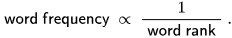

## 4. Answering queries

Queries are preprocessed with the same pipeline as documents and represented as a `Counter` `{term: frequency}`.

**Boolean retrieval** ([*IIR* ch. 1](https://nlp.stanford.edu/IR-book/html/htmledition/boolean-retrieval-1.html)) returns the set of documents that contain **all** query terms. Postings lists are sorted by `doc_id`, so we intersect them with the linear two-pointer merge, starting from the **shortest** lists to keep intermediate results small. If any query term is absent from the index, the answer is empty.

**Okapi BM25** ([Wikipedia](https://en.wikipedia.org/wiki/Okapi_BM25#The_ranking_function)) scores a document $D$ for a query $Q$ as

$$
\operatorname{score}(D,Q)=\sum_{t\in Q}\operatorname{IDF}(t)\cdot
\frac{f(t,D)\,(k_1+1)}{f(t,D)+k_1\left(1-b+b\,\frac{|D|}{\text{avgdl}}\right)},
\qquad
\operatorname{IDF}(t)=\ln\!\left(\frac{N-n(t)+0.5}{n(t)+0.5}+1\right)
$$

where $f(t,D)$ is the term frequency, $|D|$ the document length, $N$ the number of documents and $n(t)$ the document frequency. The `+1` inside the logarithm keeps IDF positive even for terms that occur in more than half of the documents; the classic form without it gives *negative* scores for such terms, which is especially noticeable in small collections.

In [ ]:
class QueryProcessing:

    _prep = Preprocessor()          # shared: reuses the stem cache across queries

    @staticmethod
    def prepare_query(raw_query):
        return Counter(QueryProcessing._prep.preprocess(raw_query))

    # ------------------------------------------------------------------ Boolean
    @staticmethod
    def _intersect(p1, p2):
        # Two-pointer merge of two sorted doc-id lists (IIR, Fig. 1.6).
        answer, i, j = [], 0, 0
        while i < len(p1) and j < len(p2):
            ...
            # TODO
        return answer

    @staticmethod
    def boolean_retrieval(query, index):
        # Set of doc ids containing all query terms.
        if not query or any(term not in index for term in query):
            return set()
        ...
        # TODO

        return set(...)

    # ------------------------------------------------------------------ BM25
    @staticmethod
    def okapi_scoring(query, doc_lengths, index, k1=1.2, b=0.75):
        # {doc_id: BM25 score} for every document containing at least one query term.
        scores = {}
        
        ...
        # TODO

        return scores

    @staticmethod
    def search(raw_query, indexer, top_k=10, **bm25_params):
        # Convenience wrapper: ranked [(doc_id, score)] for a raw query string.
        q = QueryProcessing.prepare_query(raw_query)
        scores = QueryProcessing.okapi_scoring(q, indexer.doc_lengths, indexer.index, **bm25_params)
        return nlargest(top_k, scores.items(), key=lambda kv: kv[1])

### Tests

In [20]:
test_doc_lengths = {1: 20, 2: 15, 3: 10, 4: 20, 5: 30}
test_index = {'x': [2, (1, 1), (2, 1)],
              'y': [2, (1, 1), (3, 1)],
              'z': [3, (2, 1), (4, 2)]}

test_query1 = QueryProcessing.prepare_query('x z')
test_query2 = QueryProcessing.prepare_query('x y')

assert QueryProcessing.boolean_retrieval(test_query1, test_index) == {2}
assert QueryProcessing.boolean_retrieval(test_query2, test_index) == {1}
assert QueryProcessing.boolean_retrieval(QueryProcessing.prepare_query('x unknown'), test_index) == set()
assert QueryProcessing.boolean_retrieval(QueryProcessing.prepare_query(''), test_index) == set()

okapi_res = QueryProcessing.okapi_scoring(test_query2, test_doc_lengths, test_index)
assert all(k in okapi_res for k in (1, 2, 3))
assert not any(k in okapi_res for k in (4, 5))
assert okapi_res[1] > okapi_res[3] > okapi_res[2]
assert all(s > 0 for s in okapi_res.values())
print("QueryProcessing: all tests passed")

QueryProcessing: all tests passed


### 4.1 Querying the real index

In [19]:
queries = ["skin care", "presidential election", "climate change", "stock market"]
TOP_K = 5

for q in queries:
    qobj = QueryProcessing.prepare_query(q)
    print(f"Query: {q!r}  ->  terms {dict(qobj)}")

    t0 = time.perf_counter()
    bool_res = QueryProcessing.boolean_retrieval(qobj, indexer.index)
    t1 = time.perf_counter()
    print(f"  Boolean AND: {len(bool_res)} docs  ({(t1 - t0) * 1e3:.2f} ms)")
    for doc_id in sorted(bool_res)[:TOP_K]:
        print("     ", indexer.doc_urls[doc_id])

    t0 = time.perf_counter()
    ranked = QueryProcessing.search(q, indexer, top_k=TOP_K)
    t1 = time.perf_counter()
    print(f"  BM25 top-{TOP_K}  ({(t1 - t0) * 1e3:.2f} ms)")
    for rank, (doc_id, score) in enumerate(ranked, start=1):
        print(f"    {rank}. {score:6.3f}  {indexer.doc_urls[doc_id]}")
    print()

Query: 'skin care'  ->  terms {'skin': 1, 'care': 1}
  Boolean AND: 2 docs  (0.03 ms)
      https://www.nbcnews.com/select/shopping/walmart-october-deal-days-announcement-2026-rcna598998
      https://www.nbcnews.com/select/shopping/amazon-buys-under-50-october-prime-day-2026-rcna599293
  BM25 top-5  (0.15 ms)
    1.  7.561  https://www.nbcnews.com/select/shopping/walmart-october-deal-days-announcement-2026-rcna598998
    2.  6.784  https://www.nbcnews.com/select/shopping/amazon-buys-under-50-october-prime-day-2026-rcna599293
    3.  4.680  https://www.nbcnews.com/select/shopping/early-october-prime-day-deals-2026-rcna597786
    4.  2.878  https://www.nbcnews.com/health/cancer/cancer-blood-test-faces-high-stakes-fda-review-rcna599426
    5.  2.570  https://www.nbcnews.com/health/recall/160000-pounds-meat-recalled-lack-inspection-rcna599530

Query: 'presidential election'  ->  terms {'presidenti': 1, 'elect': 1}
  Boolean AND: 5 docs  (0.02 ms)
      https://www.nbcnews.com/business/eco